# Experiment 3: sampling and accumulation during training

Compare one sampled batch per table visit, a reshuffled disjoint full pass with one optimizer step per chunk, and the same full pass with one averaged-gradient optimizer step. There are 96 trials. The PD policy here is proportional within all three arms; it is not exchangeable with balanced-PD sampling in experiment 1.

## 0. Evidence and scope

The availability tables distinguish observed measurements from unavailable outcomes. Missing measurements are not zero effects.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
REPO = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'pyproject.toml').is_file())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
from src.visualize import style, campaign as cp, publication as pub, diagnostics as dg
from src.visualize.figures import FigureSaver
from src.visualize.inputs import source_description
from src.data.dataset_names import display_frame
style.apply()
sink = FigureSaver('experiment3/01_training')
report = cp.NotebookReport('Experiment 3: sampling and accumulation during training', sink=sink)

print(source_description())
report.add('0. Evidence and scope', source_description())
from src.visualize import pilots as pv, optimization as op

DATA: no external source selected.
Project: no external source selected.
Missing project records are unavailable evidence, not zero effects or failed training.


## 1. Protocol coverage

The same reference recipe, bases and dataset partitions are used within this experiment; only the traversal/update protocol varies.

,evidence,records,origin
0,Planned trials,48,Config; not scheduler state
1,Completed trials,0,DATA manifests
2,Epoch rows,0,Project training diagnostics
3,Milestone rows,0,Project trajectory diagnostics
4,Benchmark folds,0,Project final evaluation


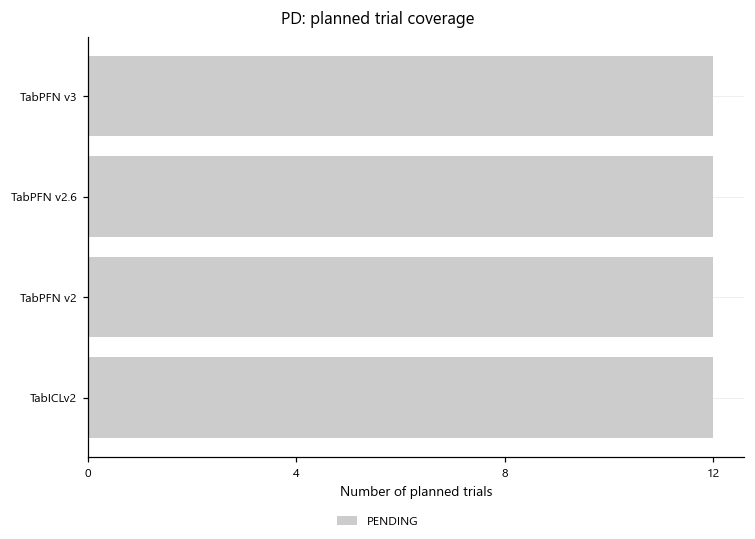

PD. Recorded status of 48 planned PD trials by base model. PENDING denotes no manifest outcome and can include currently running or queued jobs. INTERRUPTED denotes saved progress, not a numerical failure. This figure does not query the scheduler.

,evidence,records,origin
0,Planned trials,48,Config; not scheduler state
1,Completed trials,0,DATA manifests
2,Epoch rows,0,Project training diagnostics
3,Milestone rows,0,Project trajectory diagnostics
4,Benchmark folds,0,Project final evaluation


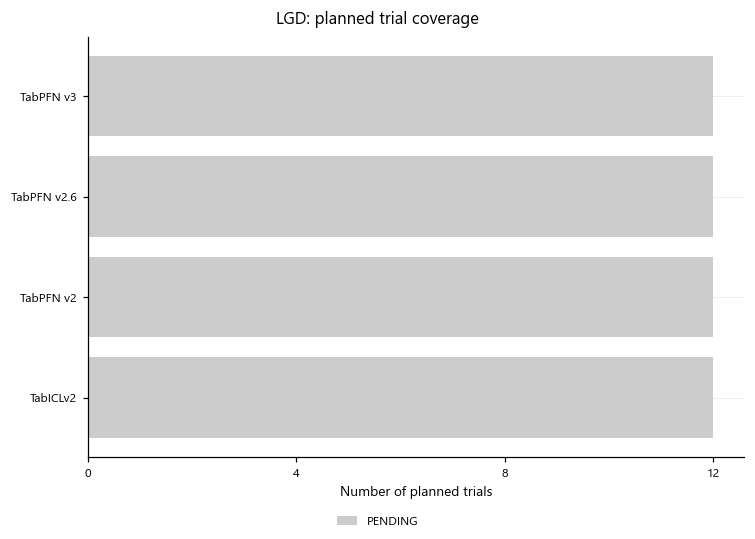

LGD. Recorded status of 48 planned LGD trials by base model. PENDING denotes no manifest outcome and can include currently running or queued jobs. INTERRUPTED denotes saved progress, not a numerical failure. This figure does not query the scheduler.

In [2]:
runs = [cp.load_campaign(3, track) for track in ('pd','lgd')]
for run in runs:
    report.table(run.track.upper()+' evidence', pub.availability(run))
    cp.show(sink, cp.plot_coverage(run), track=run.track)
report.add('1. Protocol coverage', '\n\n'.join(cp.coverage_summary(run) for run in runs))


## 2. Loss and optimizer dynamics

Loss, gradients, clipping and parameter drift are shown through training at the fixed reference recipe.

No measurements available for this section yet.


""


No measurements available for this section yet.


""


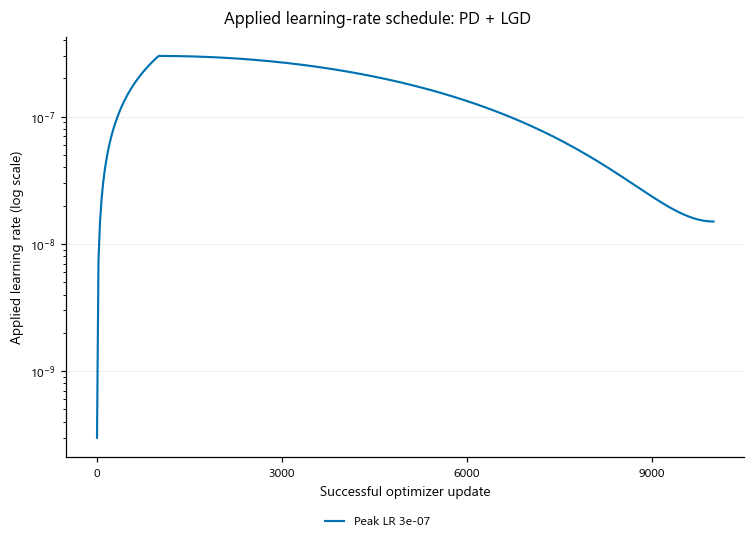

Learning rates evaluated from the recorded campaign configuration using the training scheduler. Each distinct peak-rate schedule is drawn once, pooling tasks only when budget, warmup and decay floor agree. The rate for update u is the scheduler value before that update (index u minus one). The first update has zero learning rate and is omitted from the logarithmic axis, but retained in the table. These are configured schedules; measured epoch-end rates and their sampling intervals are reported separately.

In [3]:
for run in runs:
    cp.show(sink, pv.plot_process_overview(run), track=run.track)
    for label, frame in cp.loss_coverage_tables(run).items():
        report.table(run.track.upper()+' '+label, frame)
cp.show(sink, pv.plot_schedule(list(runs)))
report.add('2. Loss and optimizer dynamics', 'Missing observations remain unavailable; partial table-coverage loss epochs are reported separately. Shared task schedules are drawn once.')

## 3. Equal-update comparison

One optimizer step represents different amounts of data and work across these protocols.

In [4]:
for run in runs:
    cp.show(sink, cp.plot_sampling_trajectories(run), track=run.track)
report.add('3. Equal-update comparison', 'Curves summarize matched held-out dataset effects, not equal compute budgets.')


No measurements available for this section yet.
No measurements available for this section yet.


## 4. Row-exposure comparison

Replot the same milestones against processed row exposures, counting repeated rows. No interpolation pretends the protocols consumed identical rows.

In [5]:
for run in runs:
    cp.show(sink, cp.plot_sampling_trajectories(run, row_exposure=True), track=run.track)
report.add('4. Row-exposure comparison', 'Exposure is the median cumulative row count at each observed update milestone.')


No measurements available for this section yet.
No measurements available for this section yet.


## 5. Resources and parameter movement

Sampled device counters and anchored-tensor movement accompany learning curves.

In [6]:
for run in runs:
    cp.show(sink, dg.plot_resource_curves(run), track=run.track)
    cp.show(sink, op.plot_movement(run), track=run.track)
    report.table(run.track.upper()+' training costs', pub.cost_summary(run))
report.add('5. Resources and parameter movement', 'Device-level samples are not integrated energy or billed allocation time.')

No measurements available for this section yet.
No measurements available for this section yet.


""


No measurements available for this section yet.
No measurements available for this section yet.


""


## 6. Non-credit trajectories

The non-credit panel tracks retention at fixed training milestones.

In [7]:
for run in runs:
    cp.show(sink, cp.plot_trajectory_pages(run, split='ood'), track=run.track)
report.add('6. Non-credit trajectories', 'Retention monitors are separate from the final five-fold benchmark.')

No measurements available for this section yet.
No measurements available for this section yet.


## Complete text summary

Complete numerical values and figure captions, following the section order above.

In [8]:
print(report.summary(sink))

Experiment 3: sampling and accumulation during training

0. Evidence and scope
DATA: no external source selected.
Project: no external source selected.
Missing project records are unavailable evidence, not zero effects or failed training.

1. Protocol coverage
Run cpt_sampling_v5; PD; 48 planned trials; target 10,000 successful updates.
status
PENDING    48
0 trajectory records; 0 benchmark fold records.
PENDING means no recorded outcome; it can include running or queued work. This is not live scheduler state.

Run cpt_sampling_v5; LGD; 48 planned trials; target 10,000 successful updates.
status
PENDING    48
0 trajectory records; 0 benchmark fold records.
PENDING means no recorded outcome; it can include running or queued work. This is not live scheduler state.

Table: PD evidence
           evidence  records                          origin
0    Planned trials       48     Config; not scheduler state
1  Completed trials        0                  DATA manifests
2        Epoch rows     